# EDA. Прокат велосипедов в Сеуле

Работаем с [данными](https://raw.githubusercontent.com/obulygin/content/main/SeoulBike/seoul_bike_data.csv) сервиса проката велосипедов в Корее за год.

Описание данных:
- Date - дата;
- Rented Bike Count - сколько велосипедов было взято в прокат, целевая переменная;
- Hour - час дня;
- Temperature - температура воздуха в градусах Цельсия;
- Humidity - влажность воздуха;
- Wind Speed - скорость ветра в м/с;
- Visibility - мера различимости объектов на расстоянии в 10 метров;
- Dew point temperature -  температура, зарегистрированная в начале дня, в градусах Цельсия;
- Solar Radiation - интенсивность солнечного света;
- Rainfall - количество осадков в мм;
- Snowfall - количество выпавшего снега в мм;
- Seasons - время года;
- Holiday - является ли день праздничным;
- Functioning Day - маркер, работал ли сервис проката в указанное время.

**Цель работы**: подробно изучить данные, в частности выявить факторы влияющие на спрос велосипедов.

**Задачи**:  
1) Провести предобработку данных: проверить данные на наличие выбросов, ошибочных значений, пропусков, дубликатов и некорректных типов.  
2) Провести EDA: реализовать все уровни анализа (одномерные/многомерные) с использованием визуализаций, изучить распределения и взаимосвязь признаков.  



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from phik import resources, report

### **1. Загрузка данных и первичный осмотр**

In [5]:
df = pd.read_csv('https://media.githubusercontent.com/media/nikitaLar-collab/My_projects/refs/heads/main/seoul_bike_data.csv?token=CDZOY2AG4ISXWEOXTXNWURTKJC7QM', encoding='cp1251')
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [7]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


1. В данных отсутствуют пропуски.
2. Колонка `Date` имеет тип данных object. Необходимо изменить его.
3. Колонки `Solar Radiation (MJ/m2)`, `Rainfall(mm)`, `Snowfall (cm)` имеют подавляющее большинство нулевых значений

### **2. Поиск частичных и полных дубликатов**

In [8]:
# Проверка на полные дубликаты
total_duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов: {total_duplicates}")

Количество полных дубликатов: 0


Проверить частичные дубликаты мы можем только двум столбцам: `Date` и `Hour`. Например, для определённого дня и часа есть вторая запись, но уже с другими значениями






In [9]:
# Проверка на частичные дубликаты
duplicates = df.duplicated(subset=['Date', 'Hour']).sum()
print(f"Количество частичных дубликатов: {duplicates}")

Количество частичных дубликатов: 0


### **3. Поиск семантических дубликатов**
Семантические дубликаты могут быть в колонках: `Date`, `Seasons`,`Holiday` и `Functioning day`.


Чтобы проверить колонку `Date` нужно конвертировать тип данных в `datetime `

In [10]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [11]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[ns]
 1   Rented Bike Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int64         
 3   Temperature(°C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind speed (m/s)           8760 non-null   float64       
 6   Visibility (10m)           8760 non-null   int64         
 7   Dew point temperature(°C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall (cm)              8760 non-null   float64       
 11  Seasons                    8760 non-null   object        
 12  Holida

Так как при конвертировании в `datetime` не было ошибок, значит все значения в колонке подходят под необходимый формат.

In [13]:
# Категориальные переменные
df.describe(include=['object', 'category']).T

,count,unique,top,freq
Seasons,8760,4,Spring,2208
Holiday,8760,2,No Holiday,8328
Functioning Day,8760,2,Yes,8465


In [14]:
print(df['Seasons'].unique())
print(df['Holiday'].unique())
print(df['Functioning Day'].unique())


['Winter' 'Spring' 'Summer' 'Autumn']
['No Holiday' 'Holiday']
['Yes' 'No']


В столбцах отсутствуют семантические дубликаты

### **4. Распределение данных и выбросы**


In [15]:
df

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [16]:
# Извлекаем компоненты даты
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['day_of_week'] = df['Date'].dt.dayofweek
df['day_name'] = df['Date'].dt.day_name()
df['quarter'] = df['Date'].dt.quarter
df['is_weekend'] = df['Date'].dt.dayofweek >= 5
df

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),...,Seasons,Holiday,Functioning Day,year,month,day,day_of_week,day_name,quarter,is_weekend
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,Winter,No Holiday,Yes,2017,12,1,4,Friday,4,False
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,Winter,No Holiday,Yes,2017,12,1,4,Friday,4,False
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,Winter,No Holiday,Yes,2017,12,1,4,Friday,4,False
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,Winter,No Holiday,Yes,2017,12,1,4,Friday,4,False
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,Winter,No Holiday,Yes,2017,12,1,4,Friday,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,...,Autumn,No Holiday,Yes,2018,11,30,4,Friday,4,False
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,...,Autumn,No Holiday,Yes,2018,11,30,4,Friday,4,False
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,...,Autumn,No Holiday,Yes,2018,11,30,4,Friday,4,False
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,...,Autumn,No Holiday,Yes,2018,11,30,4,Friday,4,False


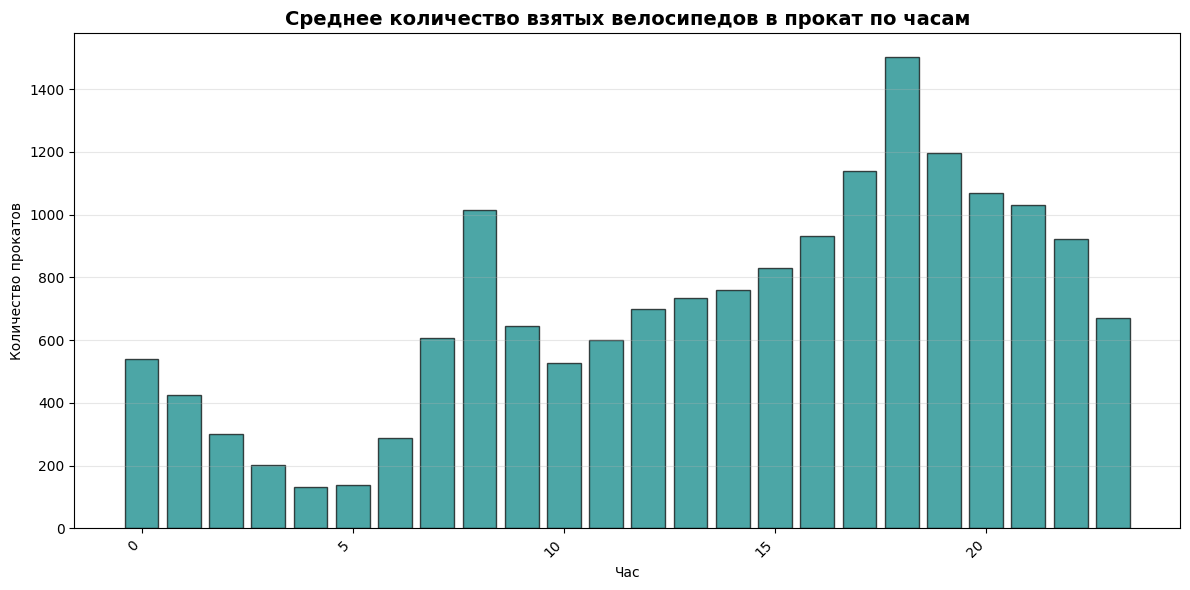

In [17]:
df_hours = df[['Rented Bike Count', 'Hour']].groupby('Hour').mean()

plt.figure(figsize=(12, 6))

plt.bar(df_hours.index, df_hours['Rented Bike Count'], color='teal', alpha=0.7, edgecolor='black')
plt.title('Среднее количество взятых велосипедов в прокат по часам', fontsize=14, fontweight='bold')
plt.xlabel('Час')
plt.ylabel('Количество прокатов')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Количество проката зависит от времени суток. В ночное время люди намного меньше берут в прокат велосипеды. Так же есть два пика на графике, в утреннее и вечернее время

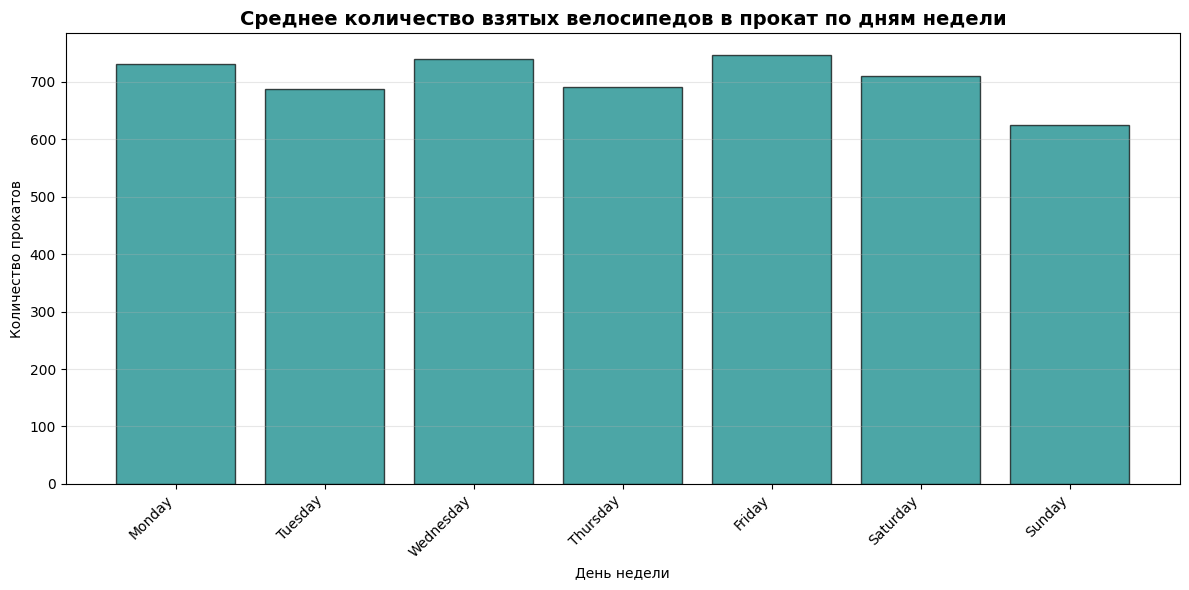

In [18]:
df_day_of_week = df[['Rented Bike Count', 'day_name']].groupby('day_name').mean()

plt.figure(figsize=(12, 6))
# Упорядочиваем по порядку дней недели
days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df2_day_of_week = df_day_of_week.reindex(days_of_week)

plt.bar(df2_day_of_week.index, df2_day_of_week['Rented Bike Count'], color='teal', alpha=0.7, edgecolor='black')
plt.title('Среднее количество взятых велосипедов в прокат по дням недели', fontsize=14, fontweight='bold')
plt.xlabel('День недели')
plt.ylabel('Количество прокатов')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

В воскресенье люди  меньше берут велосипеды в прокат. В остальные дни чередование больше-меньше

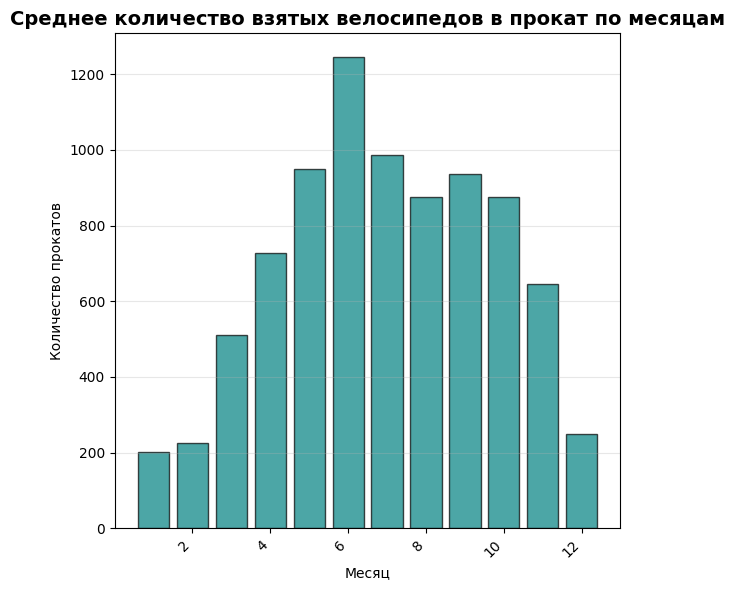

In [19]:
df_month = df[['Rented Bike Count', 'month']].groupby('month').mean()

plt.figure(figsize=(6, 6))

plt.bar(df_month.index, df_month['Rented Bike Count'], color='teal', alpha=0.7, edgecolor='black')
plt.title('Среднее количество взятых велосипедов в прокат по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Количество прокатов')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Количество проката велосипедов зависит от месяца. С 5 по 7 месяц наибольшее значение. В тёплое время года люди больше предпочитают пользоваться велосипедами. Зимой наоборот наименьшее количество

In [20]:
df_weekend = df[['Rented Bike Count', 'is_weekend']].groupby('is_weekend').mean()
df_weekend.index = df_weekend.index.astype(object)
df_weekend = df_weekend.rename(index = {False: 'Будний день', True: 'Выходной'})

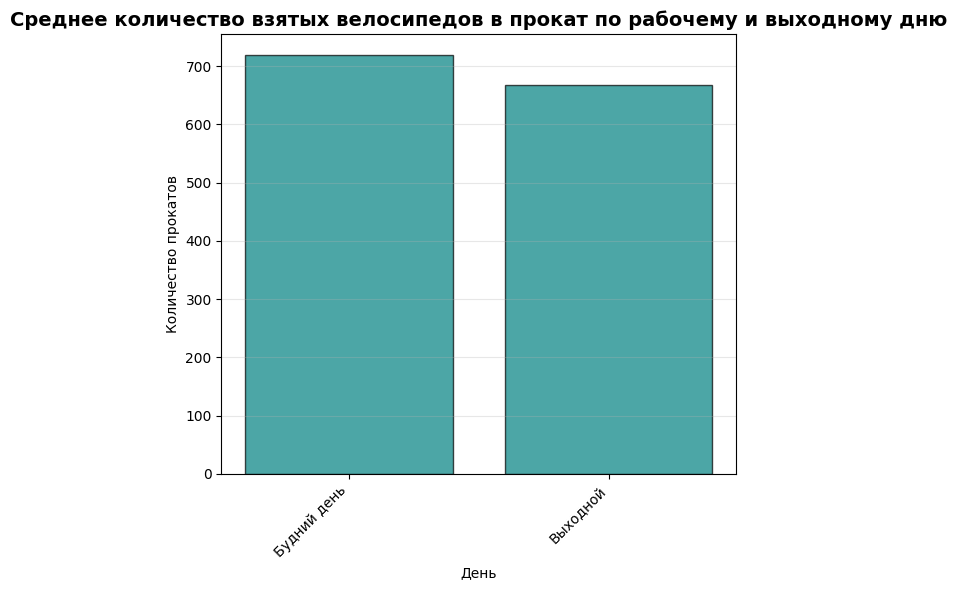

In [21]:
plt.figure(figsize=(6, 6))
plt.bar(df_weekend.index, df_weekend['Rented Bike Count'], color='teal', alpha=0.7, edgecolor='black')
plt.title('Среднее количество взятых велосипедов в прокат по рабочему и выходному дню', fontsize=14, fontweight='bold')
plt.xlabel('День')
plt.ylabel('Количество прокатов')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Количество проката слабо зависит от буднего дня или выходного

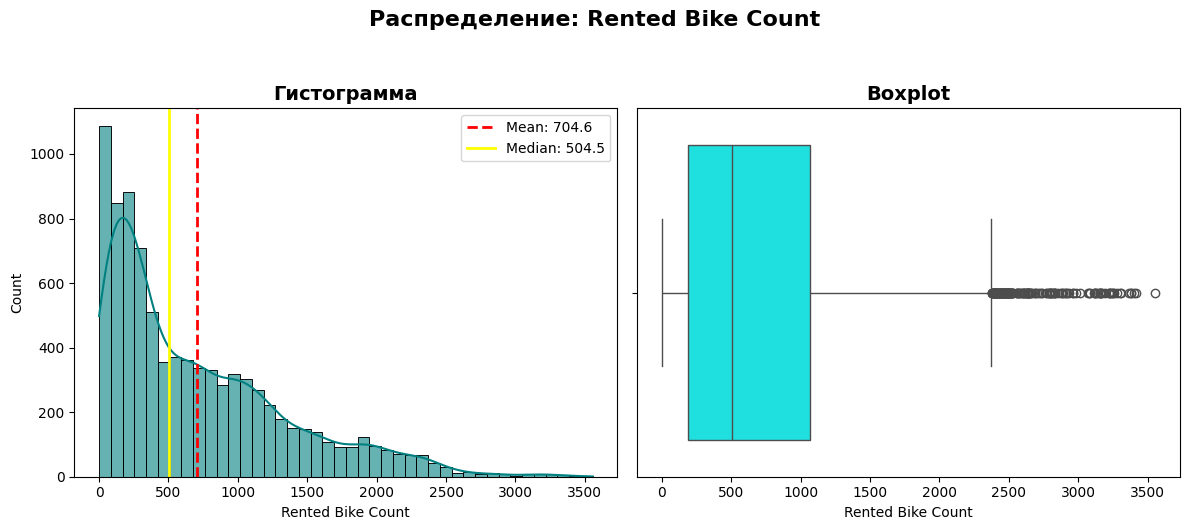

--- МЕТРИКИ ДЛЯ RENTED BIKE COUNT ---
Skewness (Скос): 1.1534 (Идеал = 0.0)
Kurtosis (Острота пика): 0.8534 (Идеал = 0.0)
⚠️ Вердикт: Сильный перекос
------------------------------


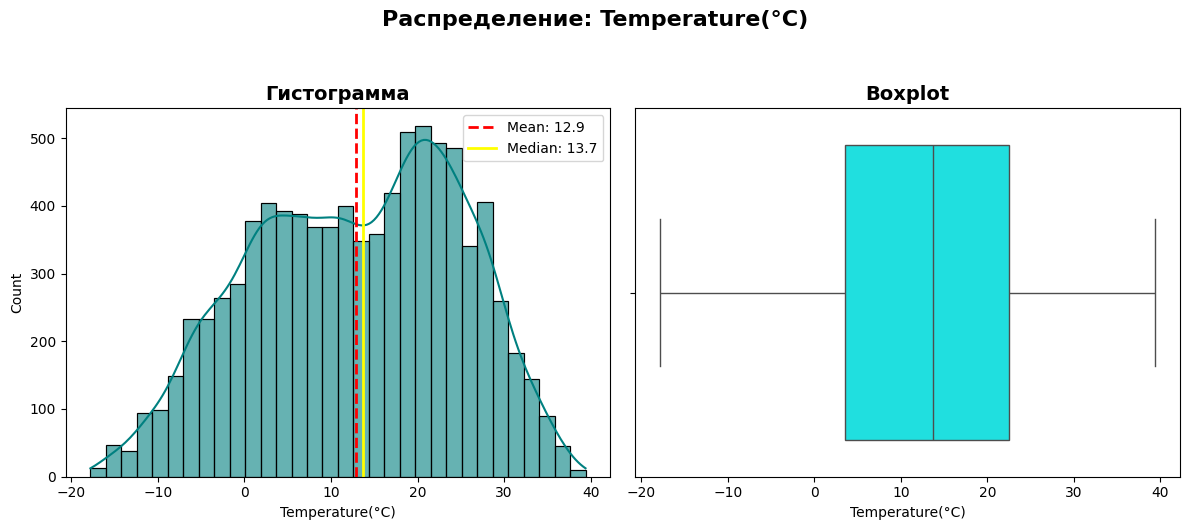

--- МЕТРИКИ ДЛЯ TEMPERATURE(°C) ---
Skewness (Скос): -0.1983 (Идеал = 0.0)
Kurtosis (Острота пика): -0.8378 (Идеал = 0.0)
✅ Вердикт: Похоже на нормальное распределение.
------------------------------


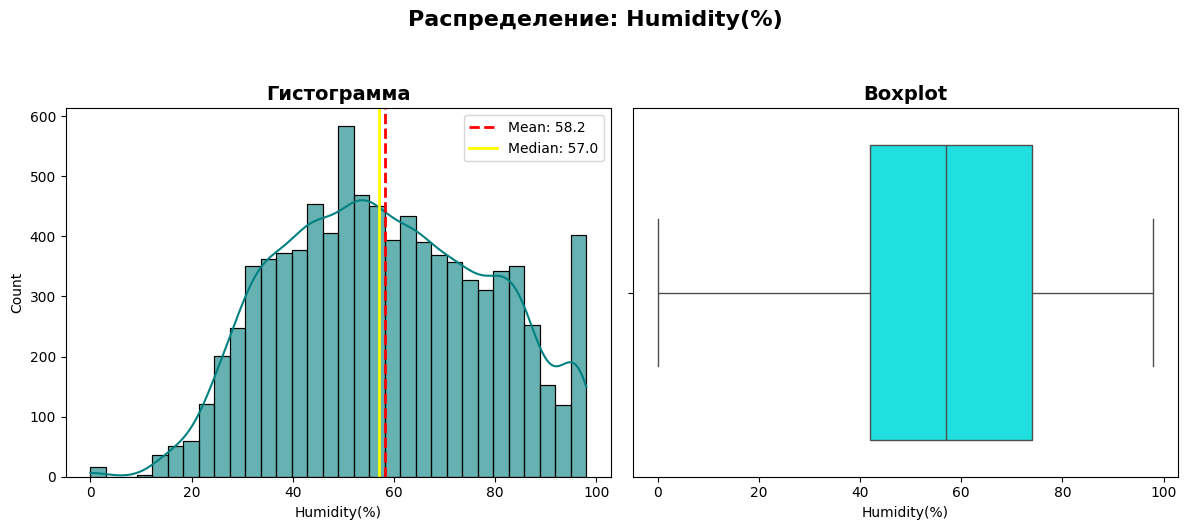

--- МЕТРИКИ ДЛЯ HUMIDITY(%) ---
Skewness (Скос): 0.0596 (Идеал = 0.0)
Kurtosis (Острота пика): -0.8036 (Идеал = 0.0)
✅ Вердикт: Похоже на нормальное распределение.
------------------------------


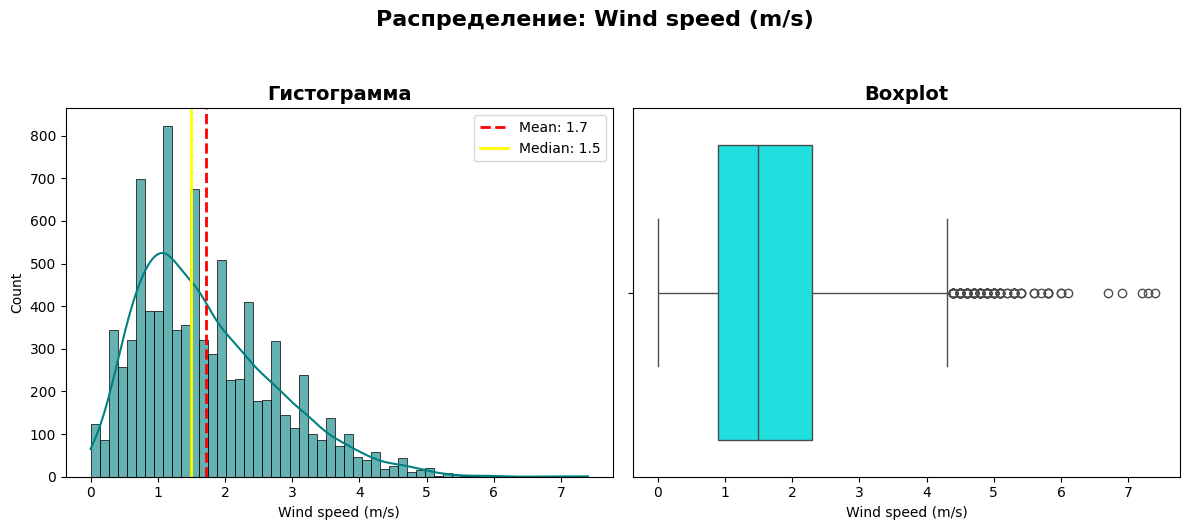

--- МЕТРИКИ ДЛЯ WIND SPEED (M/S) ---
Skewness (Скос): 0.8910 (Идеал = 0.0)
Kurtosis (Острота пика): 0.7272 (Идеал = 0.0)
ℹ️ Вердикт: Умеренный перекос.
------------------------------


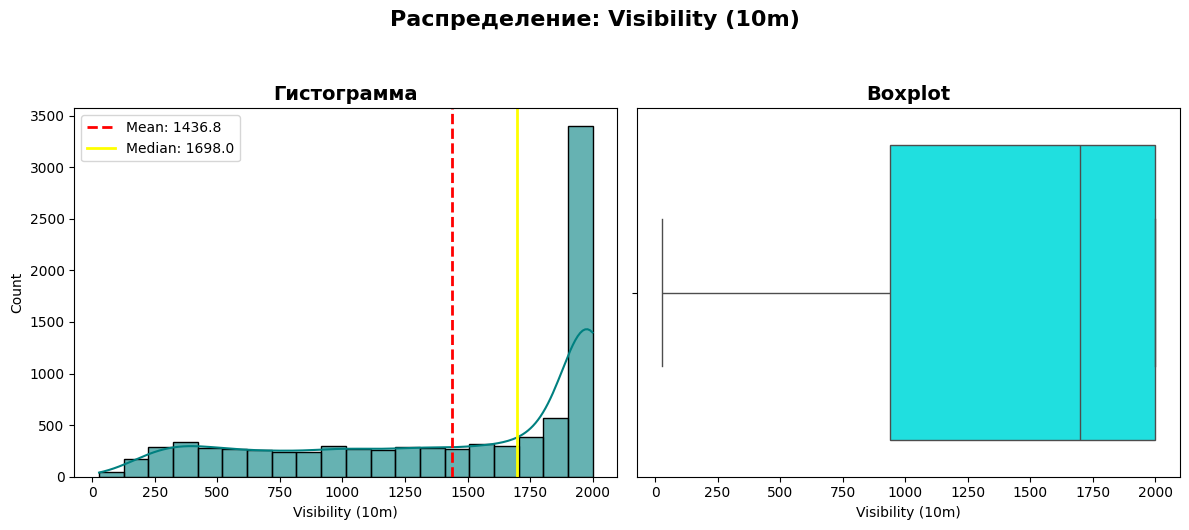

--- МЕТРИКИ ДЛЯ VISIBILITY (10M) ---
Skewness (Скос): -0.7018 (Идеал = 0.0)
Kurtosis (Острота пика): -0.9620 (Идеал = 0.0)
ℹ️ Вердикт: Умеренный перекос.
------------------------------


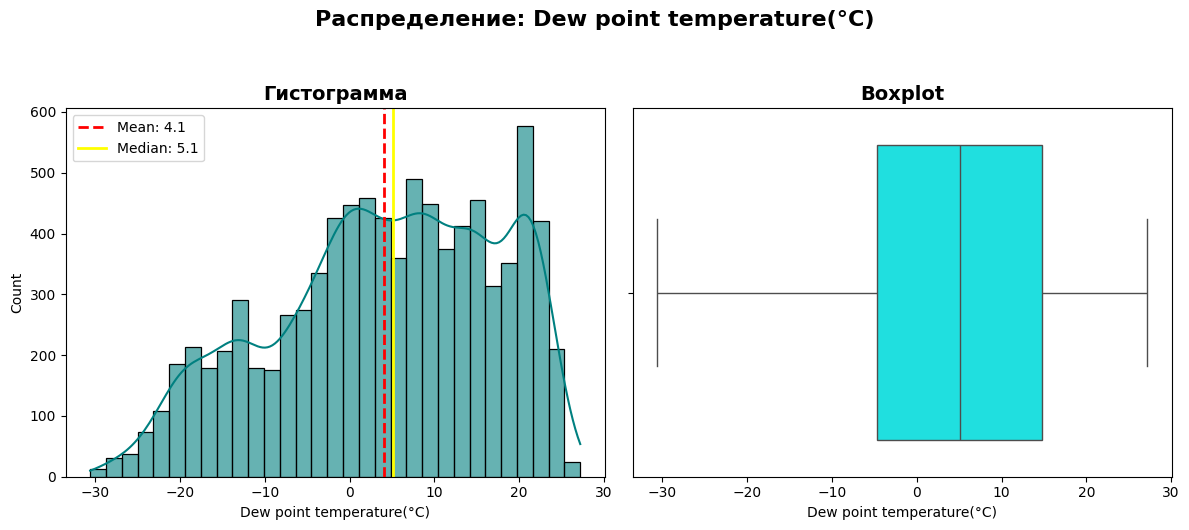

--- МЕТРИКИ ДЛЯ DEW POINT TEMPERATURE(°C) ---
Skewness (Скос): -0.3673 (Идеал = 0.0)
Kurtosis (Острота пика): -0.7554 (Идеал = 0.0)
✅ Вердикт: Похоже на нормальное распределение.
------------------------------


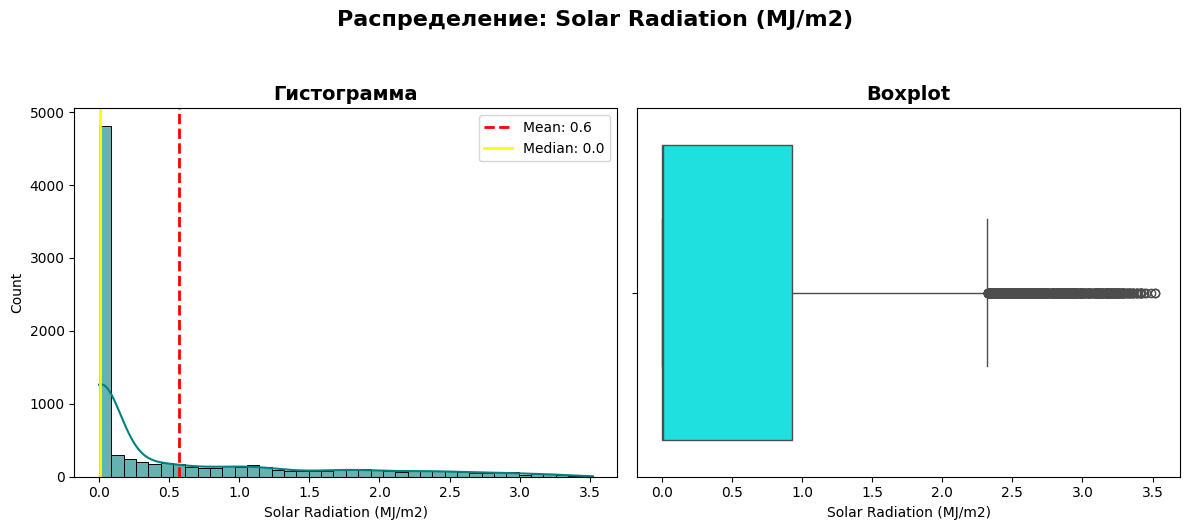

--- МЕТРИКИ ДЛЯ SOLAR RADIATION (MJ/M2) ---
Skewness (Скос): 1.5040 (Идеал = 0.0)
Kurtosis (Острота пика): 1.1264 (Идеал = 0.0)
⚠️ Вердикт: Сильный перекос
------------------------------


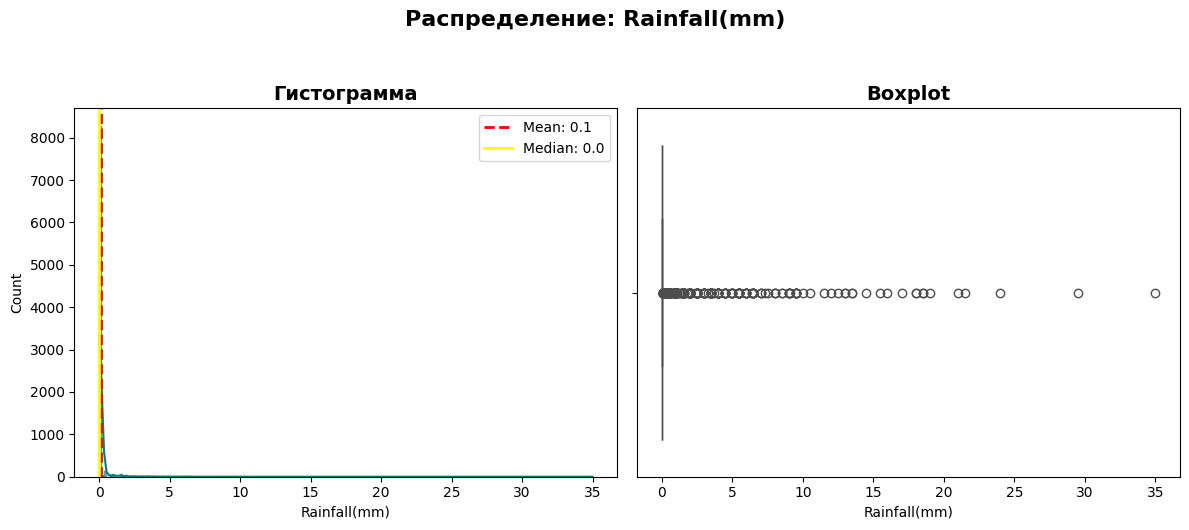

--- МЕТРИКИ ДЛЯ RAINFALL(MM) ---
Skewness (Скос): 14.5332 (Идеал = 0.0)
Kurtosis (Острота пика): 284.9911 (Идеал = 0.0)
⚠️ Вердикт: Сильный перекос
------------------------------


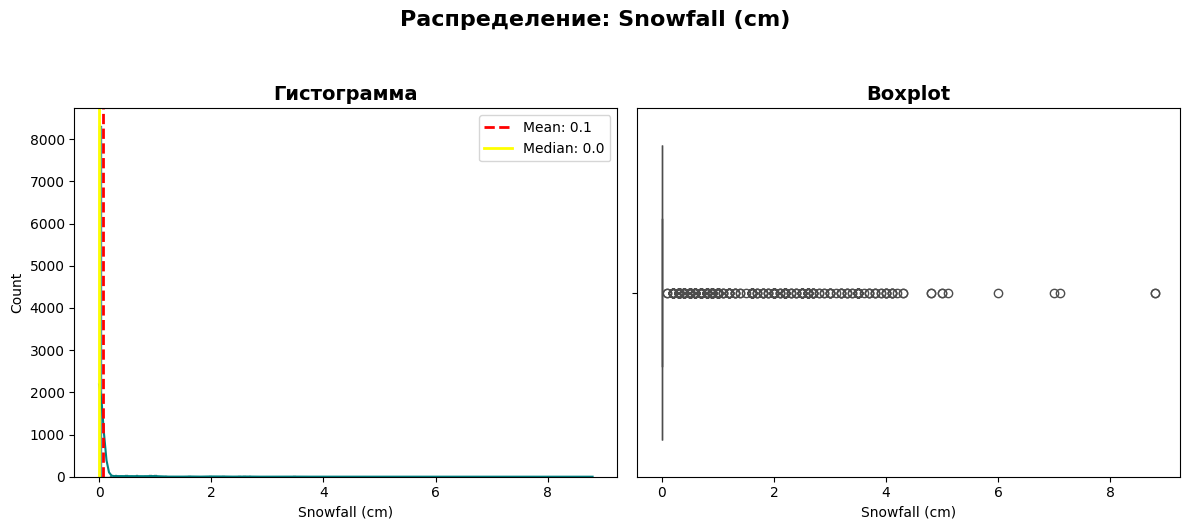

--- МЕТРИКИ ДЛЯ SNOWFALL (CM) ---
Skewness (Скос): 8.4408 (Идеал = 0.0)
Kurtosis (Острота пика): 93.8033 (Идеал = 0.0)
⚠️ Вердикт: Сильный перекос
------------------------------


In [22]:
def diagnose_distribution(df, col):
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # --- График 1: Нормальное распределение ---
  sns.histplot(df[col], kde=True, color='teal', ax=axes[0], alpha=0.6)
  mean_h = df[col].mean()
  median_h = df[col].median()

  # Линии среднего и медианы
  axes[0].axvline(mean_h, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_h:.1f}')
  axes[0].axvline(median_h, color='yellow', linestyle='-', linewidth=2, label=f'Median: {median_h:.1f}')
  axes[0].set_title('Гистограмма', fontsize=14, fontweight='bold')
  axes[0].legend()

  # Boxplot
  sns.boxplot(x=df[col], ax=axes[1], color='cyan')
  axes[1].set_title(f'Boxplot', fontsize=14, fontweight='bold')

  plt.suptitle(f'Распределение: {col}', fontsize=16, fontweight='bold', y=1.05)
  plt.tight_layout()
  plt.show()

  # Численные метрики
  skew = df[col].skew()
  kurt = df[col].kurt()

  print(f"--- МЕТРИКИ ДЛЯ {col.upper()} ---")
  print(f"Skewness (Скос): {skew:.4f} (Идеал = 0.0)")
  print(f"Kurtosis (Острота пика): {kurt:.4f} (Идеал = 0.0)")

  if abs(skew) < 0.5:
      print("✅ Вердикт: Похоже на нормальное распределение.")
  elif abs(skew) > 1:
      print("⚠️ Вердикт: Сильный перекос")
  else:
      print("ℹ️ Вердикт: Умеренный перекос.")
  print("-" * 30)

diagnose_distribution(df, 'Rented Bike Count')
diagnose_distribution(df, 'Temperature(°C)')
diagnose_distribution(df, 'Humidity(%)')
diagnose_distribution(df, 'Wind speed (m/s)')
diagnose_distribution(df, 'Visibility (10m)')
diagnose_distribution(df, 'Dew point temperature(°C)')
diagnose_distribution(df, 'Solar Radiation (MJ/m2)')
diagnose_distribution(df, 'Rainfall(mm)')
diagnose_distribution(df, 'Snowfall (cm)')

Rented Bike Count. Сильный перекос в правую сторону

Temperature(°C). Распределение похоже на нормальное, однако есть бимодальность

Humidity(%). Распределение похоже на нормальное

Wind speed (m/s). Сильный перекос в правую сторону. Всплески на распределении скорее всего из-за округления показаний датчика

Visibility (10m). Сильный перекос в левую сторону. Большая часть значений равна 2000

Dew point temperature(°C). Перекос в левую сторону.

Solar Radiation (MJ/m2). Сильный перекос в правую сторону. Большая часть значений равна 0

Rainfall(mm). Сильный перекос в правую сторону. Большая часть значений равна 0

Snowfall (cm). Сильный перекос в правую сторону. Большая часть значений равна 0


Чтобы понять влияют ли осадки на количество проката велосипедов нужно сравнить средние значений двух групп: с осадками и без

## Выбросы

Rented Bike Count. По Boxplot видно, что присутствуют выбросы с правой стороны. На самом деле данные точки выбросами не являются, это просто дни с высоким количеством проката

Temperature(°C). Отсутствуют выбросы

Humidity(%). Отсутствуют выбросы

Wind speed (m/s). Boxplot посчитал что значения 4.5-8 являются выбросами из-за скошенного распределения данных в правую стороны.

Visibility (10m). Отсутствуют выбросы

Dew point temperature(°C). Отсутствуют выбросы

Solar Radiation (MJ/m2). Из-за огромного количества значений равного нулю Boxplot определил большое количество выбросов с правой стороны. Оставляем их

Rainfall(mm). Из-за огромного количества значений равного нулю Boxplot определил большое количество выбросов с правой стороны. Оставляем их

Snowfall (cm). Из-за огромного количества значений равного нулю Boxplot определил большое количество выбросов с правой стороны. Оставляем их

Принял решение найденные выбросы оставить как есть

# 3. Корреляция

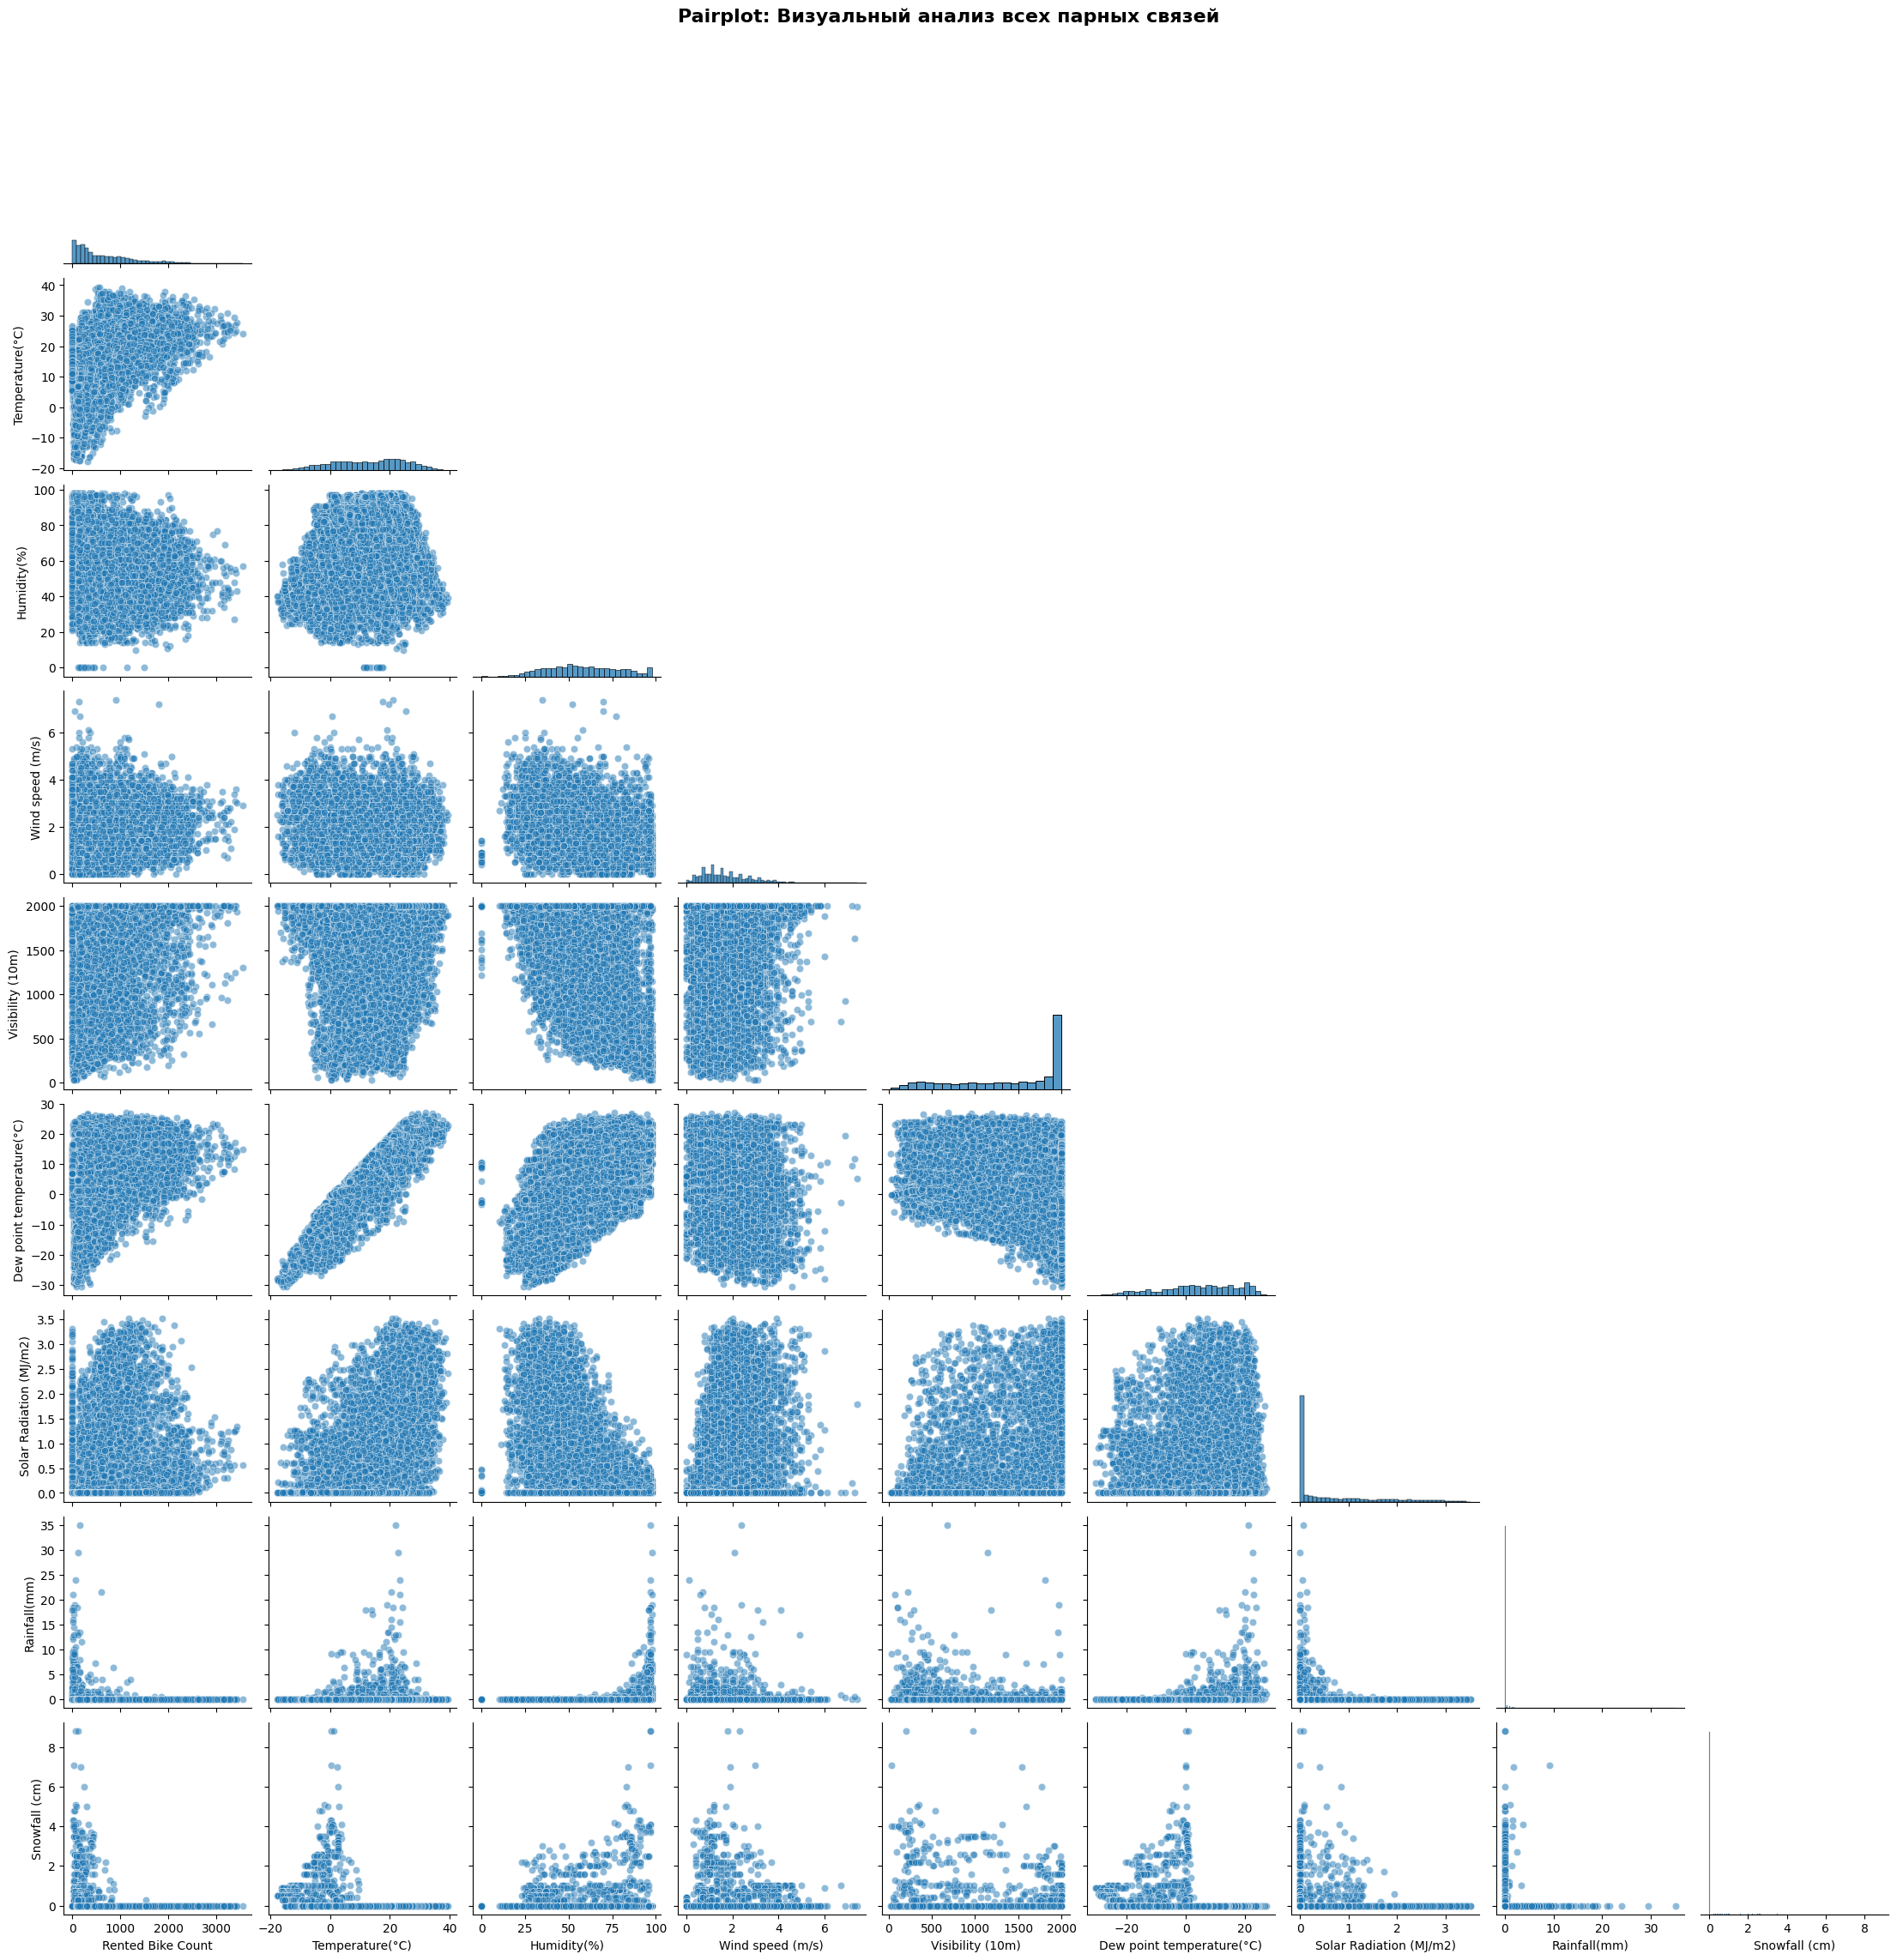

In [23]:
# Pairplot для визуального анализа всех парных связей
# Выбираем ключевые колонки
key_columns = [
    'Rented Bike Count',
    'Temperature(°C)',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Dew point temperature(°C)',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)',
]

# Строим pairplot
sns.pairplot(df[key_columns], diag_kind='hist', corner=True, plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot: Визуальный анализ всех парных связей', fontsize=16, fontweight='bold', y=1.02)
plt.show()

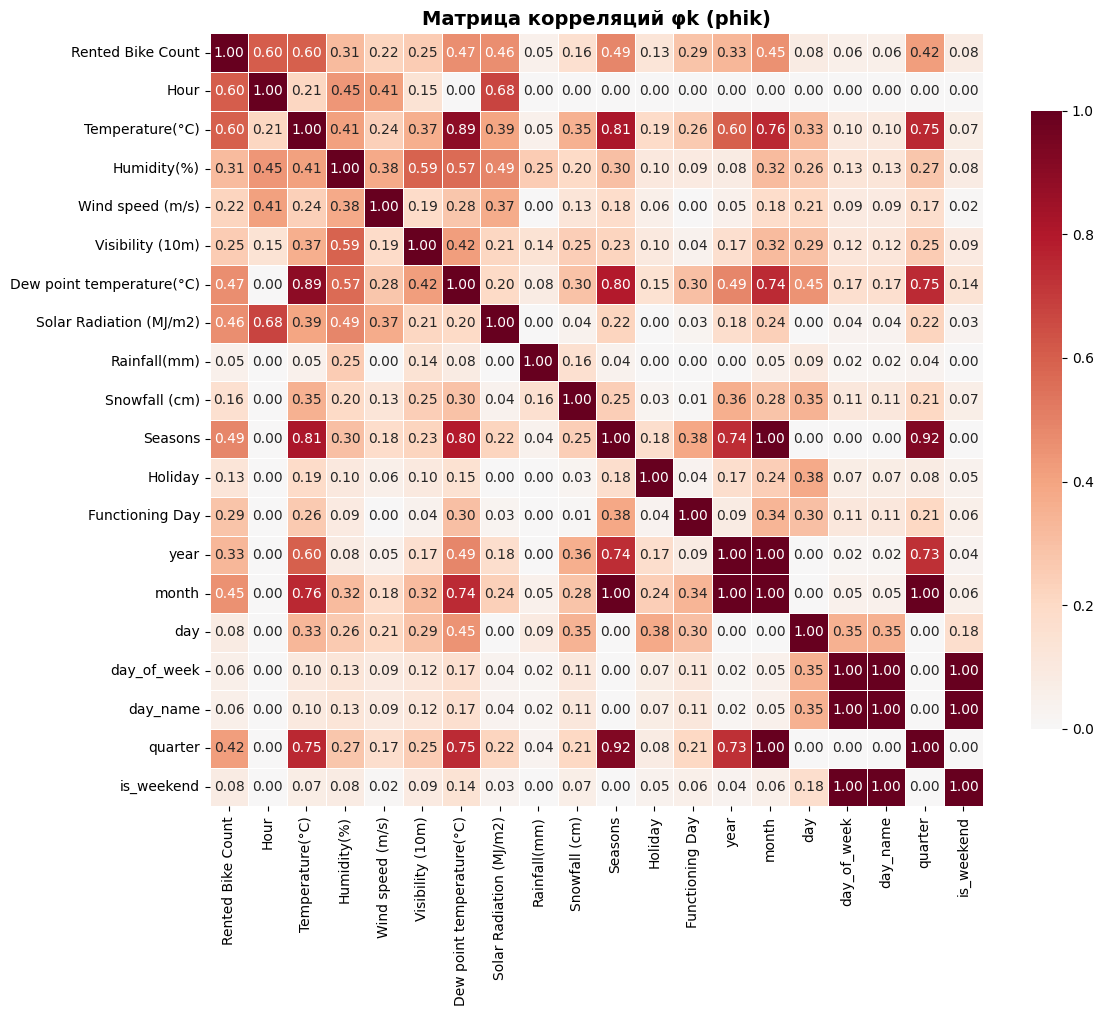

In [24]:
# Определяем интервальные (непрерывные) переменные
interval_cols = ['Rented Bike Count',
    'Temperature(°C)',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Dew point temperature(°C)',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)'
    ]

# Расчёт матрицы phik с явным указанием интервальных переменных
phik_matrix = df.drop(['Date'], axis=1).phik_matrix(interval_cols=interval_cols, )

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Матрица корреляций φk (phik)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

На матрице корреляций видна низкая взаимосвязь осадков и количества проката. Т.е. с появлением дождя или снега никак не уменьшится количество проката велосипедов. Необходимо дополнительно проверить это, сравнить средние значения проката при осадках и без

In [25]:
print(f'Среднее значение проката при наличии любых осадков: {df[(df['Rainfall(mm)'] > 0) | (df['Snowfall (cm)'] > 0)]['Rented Bike Count'].mean()}')
print(f'Среднее значение проката при отсутствии любых осадков: {df[(df['Rainfall(mm)'] == 0) | (df['Snowfall (cm)'] == 0)]['Rented Bike Count'].mean()}')

Среднее значение проката при наличии любых осадков: 175.64899257688228
Среднее значение проката при отсутствии любых осадков: 706.5558863948694


Видно что при осадках среднее количвество проката сильно меньше чем без осадков. Построим заново парные связи, но теперь только для строк, когда есть любые осадки

In [26]:
df3 = df[(df['Rainfall(mm)'] > 0) | (df['Snowfall (cm)'] > 0)]

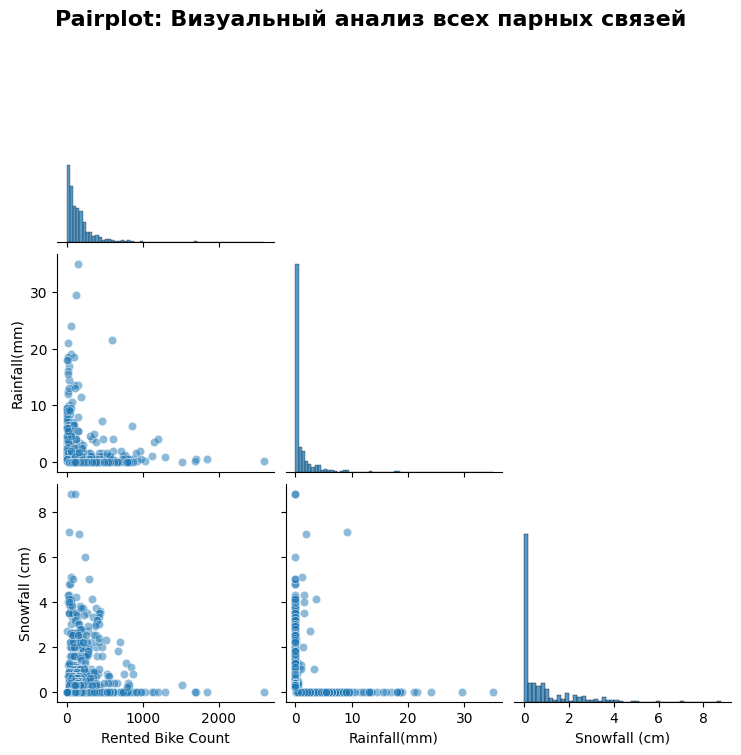

In [27]:
key_columns = [
    'Rented Bike Count',
    'Rainfall(mm)',
    'Snowfall (cm)',
]

# Строим pairplot
sns.pairplot(df3[key_columns], diag_kind='hist', corner=True, plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot: Визуальный анализ всех парных связей', fontsize=16, fontweight='bold', y=1)
plt.show()

Даже если есть небольшие осадки, тогда люди уже намного меньше берут велосипеды в прокат. Можно изменить столбцы осадков на категориальных, если осадки больше нуля, тогда 1, если равно нулю, тогда 0

In [28]:
df['is_raining'] = np.where(
    (df['Rainfall(mm)'] > 0),
    '1',
    '0'
)

df['is_snowing'] = np.where(
    (df['Snowfall (cm)'] > 0),
    '1',
    '0'
)

In [29]:
df

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),...,Functioning Day,year,month,day,day_of_week,day_name,quarter,is_weekend,is_raining,is_snowing
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,Yes,2017,12,1,4,Friday,4,False,0,0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,Yes,2017,12,1,4,Friday,4,False,0,0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,Yes,2017,12,1,4,Friday,4,False,0,0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,Yes,2017,12,1,4,Friday,4,False,0,0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,Yes,2017,12,1,4,Friday,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,...,Yes,2018,11,30,4,Friday,4,False,0,0
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,...,Yes,2018,11,30,4,Friday,4,False,0,0
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,...,Yes,2018,11,30,4,Friday,4,False,0,0
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,...,Yes,2018,11,30,4,Friday,4,False,0,0


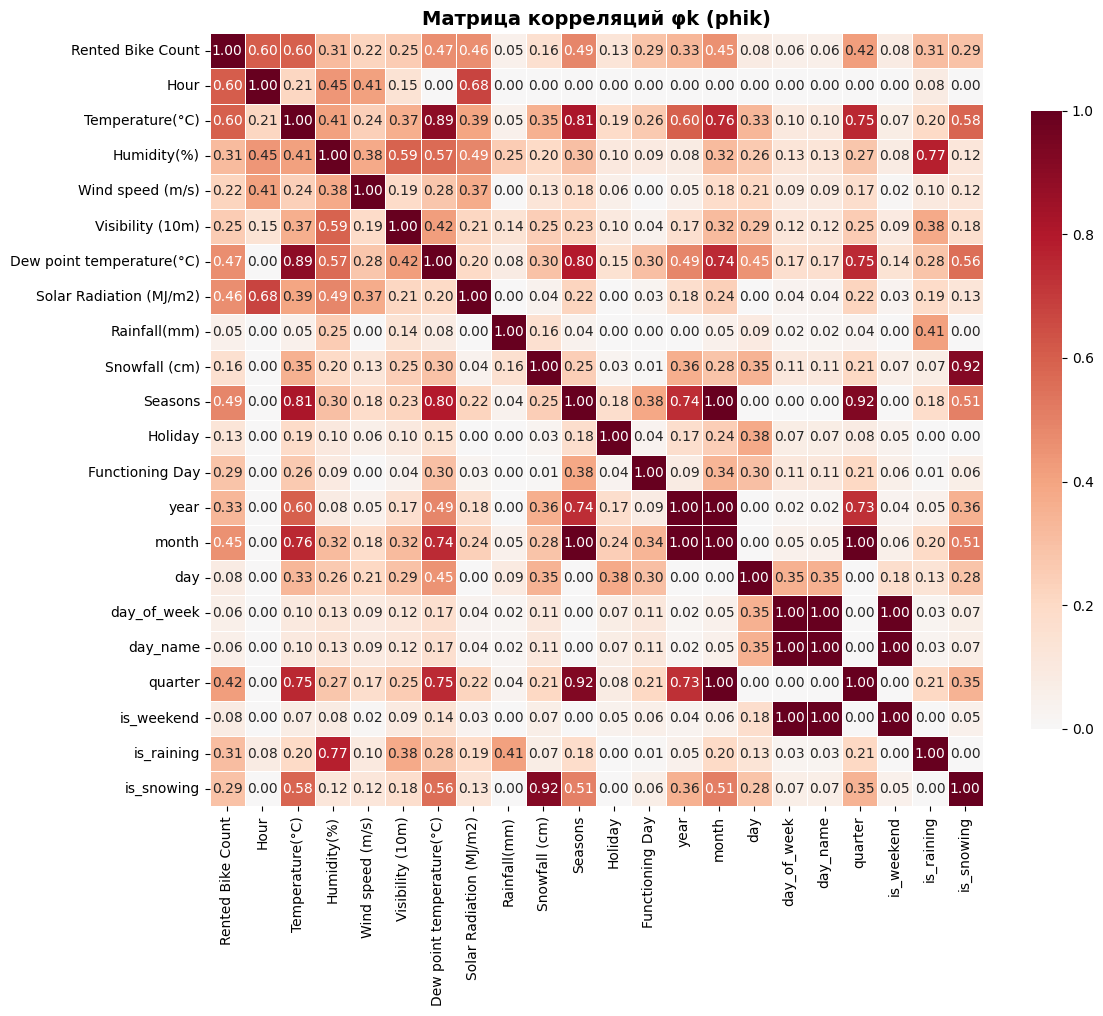

In [30]:
# Определяем интервальные (непрерывные) переменные
interval_cols = ['Rented Bike Count',
    'Temperature(°C)',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Dew point temperature(°C)',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)'
    ]

# Расчёт матрицы phik с явным указанием интервальных переменных
phik_matrix = df.drop(['Date'], axis=1).phik_matrix(interval_cols=interval_cols, )

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Матрица корреляций φk (phik)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Корреляция осадков и количества проката заметно увеличилась

# Вывод
Целевая переменная зависит от времени дня, температуры, наличия осадков. Слабо зависит от ветра, влажности и видимости